# Assignment II — Transfer Learning for NLP (Text Classification)


The task is to classify a medical transcript into the correct **medical specialty**.
### Objectives
1. Explore the dataset and understand its main characteristics.
2. Build the required baseline model: frozen **BERT + LSTM(50)**.
3. Propose a stronger model and explain why it should work better.
4. Compare both models using suitable metrics for multiclass classification.
5. Critically discuss the results from both theoretical and practical perspectives.


In [1]:

!pip install transformers datasets scikit-learn matplotlib seaborn pandas numpy torch -q

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# Create folders and set random seed for reproducibility
import os
import random

os.makedirs("../images", exist_ok=True)
os.makedirs("../model", exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Folders are ready and random seed is set to", SEED)

## 2. Load and Clean Data

using only 2 columns

- `medical_specialty` as the target label
- `transcription` as the input text

Before training the model, I cleaned the dataset by removing empty rows and clearing spaces to facilitate the subsequent training process.


In [3]:
DATA_PATH = "../data/mtsamples.csv"

df = pd.read_csv(DATA_PATH)
df = df[["medical_specialty", "transcription"]].copy()

df["medical_specialty"] = df["medical_specialty"].astype(str).str.strip()
df["transcription"] = df["transcription"].astype(str).str.strip()

df = df.replace({"transcription": {"": np.nan, "nan": np.nan, "None": np.nan}})
df = df.dropna(subset=["transcription"]).reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Unique classes:", df["medical_specialty"].nunique())
df.head()

Shape after cleaning: (4966, 2)
Unique classes: 40


,medical_specialty,transcription
0,Allergy / Immunology,"SUBJECTIVE:, This 23-year-old white female pr..."
1,Bariatrics,"PAST MEDICAL HISTORY:, He has difficulty climb..."
2,Bariatrics,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."
3,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...


## 3. Exploratory Data Analysis

I’ll start by analyzing the data to understand what’s in my dataset, its size, the categories, and the variations in text length. This is to ensure that any class imbalance doesn’t affect the evaluation results, and because text length can impact the overall performance of the model.


In [4]:
def word_count(text):
    return len(str(text).split())

df["word_count"] = df["transcription"].apply(word_count) # Calculate word count for each transcription

stats_df = pd.DataFrame([{  # Calculate statistics
    "samples": len(df),
    "classes": df["medical_specialty"].nunique(),
    "avg_words": round(df["word_count"].mean(), 2),
    "median_words": round(df["word_count"].median(), 2),
    "max_words": int(df["word_count"].max())
}])
stats_df

,samples,classes,avg_words,median_words,max_words
0,4966,40,465.45,398.0,3029


### 3.1 Class Distribution
I’m using bar charts—a simple and easy-to-understand visual format—to illustrate the sample sizes, especially when there are many categories.


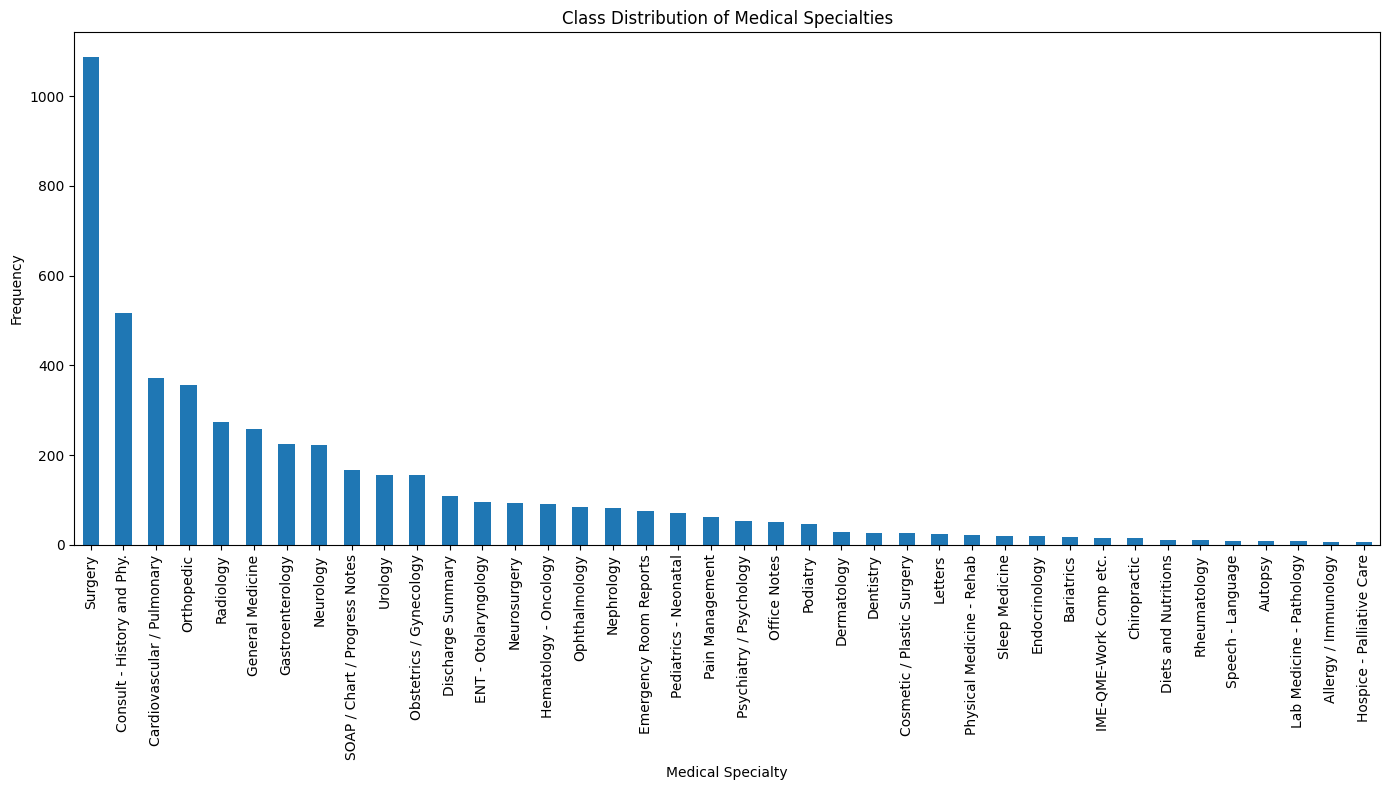

In [5]:
class_counts = df["medical_specialty"].value_counts() # Count samples per class

plt.figure(figsize=(14, 8)) 
class_counts.plot(kind="bar")
plt.title("Class Distribution of Medical Specialties")
plt.xlabel("Medical Specialty")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../images/class_distribution.svg", format="svg", bbox_inches="tight")
plt.show()

### 3.2 Transcript Length Distribution

This histogram illustrates the detailed distribution of transcript lengths. Using a histogram makes it easier to set a maximum word count when deploying the model later, thereby preventing records from being truncated.

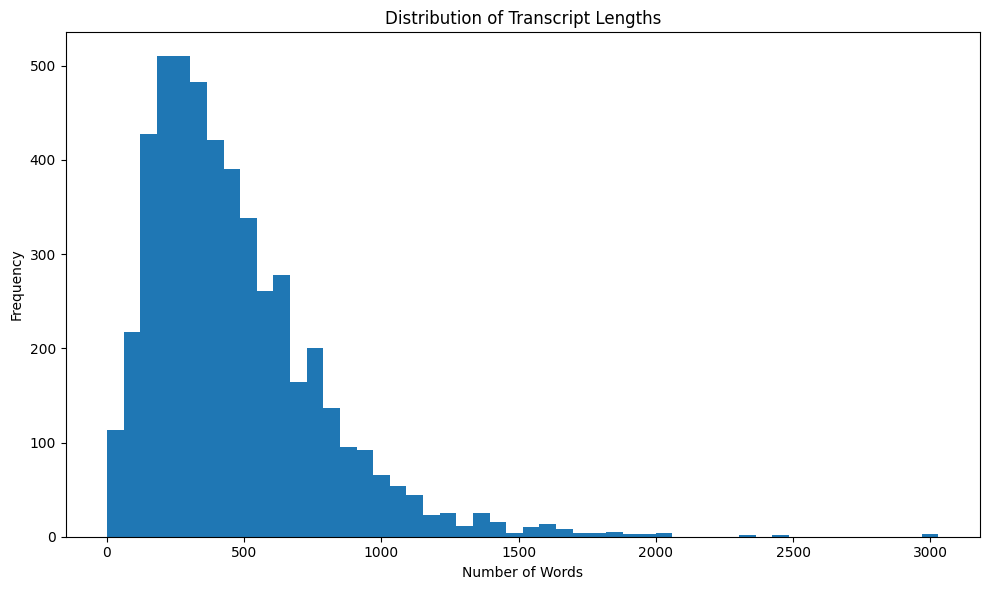

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(df["word_count"], bins=50)
plt.title("Distribution of Transcript Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../images/transcript_length_hist.svg", format="svg", bbox_inches="tight")
plt.show()

### 3.3 Length Variation Across Major Classes

Box plots are used here to compare the length of transcribed text across various high-frequency specialties and to display the median, range, and outliers for each group. Compared to a standard histogram, this comparison provides more detailed information. It reveals whether records for certain specialties are typically longer and more detailed than those for other specialties.


<Figure size 1400x600 with 0 Axes>

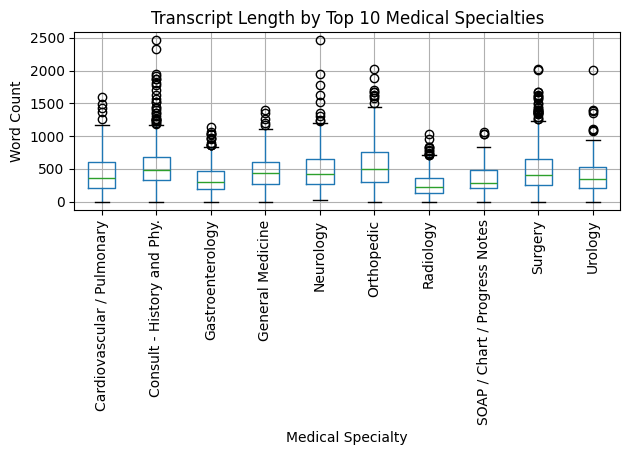

In [7]:
top_classes = class_counts.head(10).index
top_df = df[df["medical_specialty"].isin(top_classes)]

plt.figure(figsize=(14, 6))
top_df.boxplot(column="word_count", by="medical_specialty", rot=90)
plt.title("Transcript Length by Top 10 Medical Specialties")
plt.suptitle("")
plt.xlabel("Medical Specialty")
plt.ylabel("Word Count")
plt.tight_layout()
plt.savefig("../images/length_boxplot.svg", format="svg", bbox_inches="tight")
plt.show()

## 4. Workflow

The full experiment follows a clear end-to-end pipeline, shown in `images/workflow_diagram.svg`.

**Raw CSV → Column Selection → Data Cleaning → Label Encoding → Train/Validation/Test Split → Tokenization → Baseline Model → Proposed Model → Evaluation → Critique**

This workflow is easy and useful with each step has a specific purpose. The data is first cleaned, then converted into a form suitable for modeling, then used to train two different approaches, and finally evaluated with multiple metrics.


## 5. Label Encoding and Split

Since the target labels are text values, they must be converted into numerical form before training. This is achieved through label encoding, which maps each medical specialty to a unique integer ID. The preprocessed dataset is then split into a **training set**, a **validation set**, and a **test set**. A hierarchical splitting method is used to ensure that the class distributions across the three subsets remain as consistent as possible.

In [8]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["medical_specialty"])

id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}

train_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df["label"], random_state=42
)
train_df, val_df = train_test_split(
    train_df, test_size=0.1765, stratify=train_df["label"], random_state=42
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (3475, 4)
Val: (746, 4)
Test: (745, 4)


## 6. Dataset Class

Use a custom PyTorch `Dataset` class to prepare text for Transformer-based models. This class handles tokenization, truncation, padding, and label formatting, encapsulating this logic within the dataset for ease of use.


In [9]:
class MedicalTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

## 7. Baseline Model — Frozen BERT + LSTM(50)

This approach uses a baseline model that generates context embedding vectors using a pre-trained **BERT** model; however, the BERT parameters are frozen. The vectors are then fed into an **LSTM with 50 hidden units**, and the final prediction is made via a classification task. Note: Freezing BERT helps reduce computational costs for the subsequent model while also minimizing overfitting in the data.



In [10]:
BASE_MODEL_NAME = "bert-base-uncased"
baseline_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)

train_dataset_base = MedicalTextDataset(train_df["transcription"], train_df["label"], baseline_tokenizer, max_length=256)
val_dataset_base = MedicalTextDataset(val_df["transcription"], val_df["label"], baseline_tokenizer, max_length=256)
test_dataset_base = MedicalTextDataset(test_df["transcription"], test_df["label"], baseline_tokenizer, max_length=256)

train_loader_base = DataLoader(train_dataset_base, batch_size=8, shuffle=True)
val_loader_base = DataLoader(val_dataset_base, batch_size=8, shuffle=False)
test_loader_base = DataLoader(test_dataset_base, batch_size=8, shuffle=False)

In [11]:
class FrozenBertLSTM(nn.Module):  # Model with frozen BERT and LSTM classifier
    def __init__(self, model_name, num_classes, lstm_hidden_size=50): # Initialize model with frozen BERT and LSTM classifier
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        for param in self.bert.parameters():
            param.requires_grad = False

        self.lstm = nn.LSTM( # LSTM layer to process BERT outputs
            input_size=self.bert.config.hidden_size,
            hidden_size=lstm_hidden_size,
            batch_first=True
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(lstm_hidden_size, num_classes)

    def forward(self, input_ids, attention_mask): # Forward pass through the model
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            sequence_output = outputs.last_hidden_state
        _, (hidden, _) = self.lstm(sequence_output)
        x = self.dropout(hidden[-1])
        return self.fc(x)

In [12]:
def evaluate_model(model, data_loader, criterion): # Evaluate model performance on a given dataset
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in data_loader: # Iterate through batches in the data loader
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader) # Calculate average loss
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )
    weighted_f1 = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )[2]

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "weighted_f1": weighted_f1,
        "preds": all_preds,
        "labels": all_labels
    }

def train_baseline(model, train_loader, val_loader, epochs=5, lr=1e-3): # Train the baseline model with frozen BERT and LSTM classifier
    criterion = nn.CrossEntropyLoss() #     Cross-entropy loss for multi-class classification
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    best_val_f1 = -1
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs): # Loop over epochs
        model.train()
        total_loss = 0

        for batch in train_loader: # Iterate through batches in the training data loader
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)
        val_metrics = evaluate_model(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Macro-F1: {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            torch.save(model.state_dict(), "../model/baseline_model.pt")

    return history

In [13]:
num_classes = df["label"].nunique()
baseline_model = FrozenBertLSTM(BASE_MODEL_NAME, num_classes, lstm_hidden_size=50).to(device)
# Train the baseline model
baseline_history = train_baseline(baseline_model, train_loader_base, val_loader_base, epochs=5, lr=1e-3)

# Evaluate the best model on the test set
criterion = nn.CrossEntropyLoss()
baseline_model.load_state_dict(torch.load("../model/baseline_model.pt", map_location=device))
baseline_test_metrics = evaluate_model(baseline_model, test_loader_base, criterion)
baseline_test_metrics

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
W0422 22:20:21.707000 20224 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6689.80it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored

Epoch 1/5 | Train Loss: 2.8808 | Val Loss: 2.6714 | Val Macro-F1: 0.0263
Epoch 2/5 | Train Loss: 2.6918 | Val Loss: 2.6056 | Val Macro-F1: 0.0338
Epoch 3/5 | Train Loss: 2.6254 | Val Loss: 2.5294 | Val Macro-F1: 0.0406
Epoch 4/5 | Train Loss: 2.5562 | Val Loss: 2.4718 | Val Macro-F1: 0.0389
Epoch 5/5 | Train Loss: 2.4698 | Val Loss: 2.3748 | Val Macro-F1: 0.0440


{'loss': 2.3921197678180453,
 'accuracy': 0.34630872483221475,
 'macro_precision': 0.03704566989349598,
 'macro_recall': 0.0667301625819918,
 'macro_f1': 0.042144081942881675,
 'weighted_f1': 0.21097889769519856,
 'preds': [np.int64(38),
  np.int64(38),
  np.int64(38),
  np.int64(38),
  np.int64(5),
  np.int64(38),
  np.int64(38),
  np.int64(38),
  np.int64(38),
  np.int64(5),
  np.int64(33),
  np.int64(5),
  np.int64(5),
  np.int64(33),
  np.int64(5),
  np.int64(5),
  np.int64(5),
  np.int64(38),
  np.int64(38),
  np.int64(5),
  np.int64(38),
  np.int64(33),
  np.int64(38),
  np.int64(5),
  np.int64(33),
  np.int64(38),
  np.int64(38),
  np.int64(5),
  np.int64(38),
  np.int64(5),
  np.int64(5),
  np.int64(38),
  np.int64(33),
  np.int64(38),
  np.int64(5),
  np.int64(38),
  np.int64(5),
  np.int64(5),
  np.int64(33),
  np.int64(5),
  np.int64(38),
  np.int64(38),
  np.int64(38),
  np.int64(15),
  np.int64(5),
  np.int64(5),
  np.int64(38),
  np.int64(5),
  np.int64(38),
  np.int64(38

## 8. Proposed Model — Biomedical BERT

Recommended model:
'Bio_ClinicalBERT'

Because this model supports **end-to-end fine-tuning**, enabling pre-trained language representations to be directly adapted to classification tasks. Second, it is based on biomedical or clinical pre-training, which helps it understand medical terminology, abbreviations, and writing styles more effectively. Third, it employs class-weighted loss to reduce bias toward majority classes.

In [14]:
PROPOSED_MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
proposed_tokenizer = AutoTokenizer.from_pretrained(PROPOSED_MODEL_NAME)

label_counts = train_df["label"].value_counts().sort_index().values
class_weights = len(train_df) / (len(label_counts) * label_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

train_dataset_prop = MedicalTextDataset(train_df["transcription"], train_df["label"], proposed_tokenizer, max_length=256)
val_dataset_prop = MedicalTextDataset(val_df["transcription"], val_df["label"], proposed_tokenizer, max_length=256)
test_dataset_prop = MedicalTextDataset(test_df["transcription"], test_df["label"], proposed_tokenizer, max_length=256)

train_loader_prop = DataLoader(train_dataset_prop, batch_size=8, shuffle=True)
val_loader_prop = DataLoader(val_dataset_prop, batch_size=8, shuffle=False)
test_loader_prop = DataLoader(test_dataset_prop, batch_size=8, shuffle=False)

proposed_model = AutoModelForSequenceClassification.from_pretrained(
    PROPOSED_MODEL_NAME,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
).to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 35133.50it/s]
BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those para

In [ ]:
def train_transformer(model, train_loader, val_loader, class_weights=None, epochs=3, lr=2e-5):
    criterion = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None else nn.CrossEntropyLoss() # Use class weights in the loss function if provided
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr) # AdamW optimizer for transformer training

    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    best_val_f1 = -1
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs): # Loop over epochs
        model.train()
        total_loss = 0

        for batch in train_loader: # Iterate through batches in the training data loader
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask) # Forward pass through the model to get logits
            logits = outputs.logits
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)
        history["train_loss"].append(train_loss)

        model.eval()
        val_loss = 0
        all_preds, all_labels = [], []
    
        with torch.no_grad(): # Evaluate the model on the validation set 
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["label"].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask) # Forward pass through the model to get logits  
                logits = outputs.logits
                loss = criterion(logits, labels)
                val_loss += loss.item()

                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        history["val_loss"].append(val_loss)
        macro_f1 = precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)[2] # Calculate macro F1 score for validation set
    
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Macro-F1: {macro_f1:.4f}"
        )

        if macro_f1 > best_val_f1:
            best_val_f1 = macro_f1
            torch.save(model.state_dict(), "../model/proposed_model.pt")

    return history

In [ ]:
proposed_history = train_transformer( # Train the proposed model with BioClinicalBERT and class weights
    proposed_model,
    train_loader_prop,
    val_loader_prop,
    class_weights,
    epochs=3,
    lr=2e-5
)
proposed_model.load_state_dict(torch.load("../model/proposed_model.pt", map_location=device))
proposed_model.eval()

criterion = nn.CrossEntropyLoss(weight=class_weights)
all_preds, all_labels = [], []
total_loss = 0

with torch.no_grad(): # Evaluate the proposed model on the test set
    for batch in test_loader_prop: # Iterate through batches in the test data loader
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = proposed_model(input_ids=input_ids, attention_mask=attention_mask) # Forward pass through the model to get logits
        logits = outputs.logits
        loss = criterion(logits, labels)
        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

proposed_test_metrics = { # Compile test metrics for the proposed model
    "loss": total_loss / len(test_loader_prop),
    "accuracy": accuracy_score(all_labels, all_preds),
    "macro_precision": precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)[0],
    "macro_recall": precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)[1],
    "macro_f1": precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)[2],
    "weighted_f1": precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)[2],
}
proposed_test_metrics

Epoch 1/3 | Train Loss: 3.5030 | Val Loss: 3.0404 | Val Macro-F1: 0.1563
Epoch 2/3 | Train Loss: 2.7192 | Val Loss: 2.4328 | Val Macro-F1: 0.2539
Epoch 3/3 | Train Loss: 2.2233 | Val Loss: 2.2719 | Val Macro-F1: 0.2603


{'loss': 2.2878822722333543,
 'accuracy': 0.3409395973154362,
 'macro_precision': 0.25736629479334666,
 'macro_recall': 0.40800756596733273,
 'macro_f1': 0.2824408733398469,
 'weighted_f1': 0.26470947081999624}

## 9. Results and Brief Discussion

To compare the two models fairly, I used several evaluation metrics instead of relying only on accuracy. In this task, **macro F1** is especially important because the dataset is imbalanced, so performance on small classes should not be hidden by the large classes. I also report **macro precision**, **macro recall**, and **weighted F1** to provide a more complete view of model performance.

From the results table, the baseline model achieved a slightly higher **accuracy** (**0.3463**) than the proposed model (**0.3409**). However, this does not mean that the baseline is better overall. When looking at more balanced metrics, the proposed model performed much better. Its **macro F1** increased from **0.0421** to **0.2824**, and its **weighted F1** also improved from **0.2110** to **0.2647**.

This result suggests that the baseline model was strongly biased toward a small number of majority classes. By comparision, the proposed model gave more balanced predictions across different specialties. Therefore, although the proposed model did not achieve the highest accuracy, it was still the better model for current task because it deal with the class imbalance more effectively.

Overall, the result shows that **accuracy alone is not enough** for this assignment. For an imbalanced multiclass medical classification problem, **macro F1 gives a more meaningful picture of model quality**.

In [ ]:
results_df = pd.DataFrame([ # Compile results into a DataFrame for comparison
    {
        "Model": "Baseline (Frozen BERT + LSTM50)",
        "Accuracy": baseline_test_metrics["accuracy"],
        "Macro Precision": baseline_test_metrics["macro_precision"],
        "Macro Recall": baseline_test_metrics["macro_recall"],
        "Macro F1": baseline_test_metrics["macro_f1"],
        "Weighted F1": baseline_test_metrics["weighted_f1"]
    },
    {
        "Model": "Proposed (Fine-tuned Bio_ClinicalBERT)",
        "Accuracy": proposed_test_metrics["accuracy"],
        "Macro Precision": proposed_test_metrics["macro_precision"],
        "Macro Recall": proposed_test_metrics["macro_recall"],
        "Macro F1": proposed_test_metrics["macro_f1"],
        "Weighted F1": proposed_test_metrics["weighted_f1"]
    }
])

results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Baseline (Frozen BERT + LSTM50),0.346309,0.037046,0.066730,0.042144,0.210979
1,Proposed (Fine-tuned Bio_ClinicalBERT),0.340940,0.257366,0.408008,0.282441,0.264709


## 10. Model Critique

### Theoretical Perspective

From a theoretical point of view, the baseline model is a reasonable starting point, but it also has clear limitations. In this study, BERT is used as a frozen encoder, so it works mainly as a fixed contextual feature extractor. This design is useful for building a simple baseline, and it is consistent with the original BERT framework, where pretrained representations can be used either as fixed features or through task-specific fine-tuning [1]. However, once BERT is frozen, its internal representations cannot adapt to the current medical specialty classification task. This means that most task-specific learning must be handled by the LSTM and the final classifier.

Another limitation is that the LSTM only has 50 hidden units, which gives the baseline model limited learning capacity. This may not be enough for a difficult multiclass task and clinical expressions. This is also consistent with the result of the baseline model in this experiment, where the macro F1 score is very low. In other words, the baseline may still capture common patterns, but it struggles to make balanced predictions across all classes.

The proposed model is theoretically stronger because it allows end-to-end fine-tuning and uses a domain-related pretrained model. This is important because biomedical and clinical language is different from general English. BioBERT was introduced exactly to address this domain gap, and the authors reported that pretraining on biomedical corpora helped the model perform better on biomedical text mining tasks than general BERT [2]. In a similar way, ClinicalBERT was developed for clinical notes and was shown to produce useful clinical text representations and outperform baselines on a clinical prediction task [3]. Based on these studies, it is reasonable that the proposed model in this assignment achieved a much higher macro F1 score than the baseline.

### Practical Perspective

From a practical perspective, the proposed model is more useful for this task, even though its accuracy is slightly lower than the baseline. In an imbalanced multiclass problem, accuracy alone can be misleading because a model may appear acceptable simply by performing well on the largest classes. In contrast, the much better macro F1 score of the proposed model shows that it makes more balanced predictions across specialties. For a medical text classification task, this is more meaningful than only improving overall accuracy, because the system should not ignore less frequent specialties.
At the same time, the stronger model also comes with higher cost. Fine-tuning a transformer requires more computation, more memory, and more careful hyperparameter selection than using frozen embeddings [1]. Therefore, the baseline still has practical value as a lightweight benchmark. It is easier to train and easier to reproduce. However, when the goal is better performance on specialized medical text, domain-specific pretrained models such as BioBERT or ClinicalBERT are usually a more suitable choice [2][3].

### Existing Limitations

Although the proposed model performed better overall, several limitations still remain. First, class imbalance is still a challenge, especially for classes with very small numbers of samples. Second, some transcripts are long, so truncation may remove useful information before the text reaches the model. Third, predicting the correct medical specialty is helpful, but it is not the same as predicting a final diagnosis. Finally, the dataset is still limited in size for a multiclass medical NLP task, so the model may not generalize well to other datasets or real clinical settings.

Overall, the comparison in this assignment supports the idea that stronger task adaptation and domain-specific pretraining are useful for medical NLP [1][2][3]. At the same time, the remaining errors suggest that there is still room for improvement in handling rare classes, long documents, and more realistic clinical decision support.

## References

[1] J. Devlin, M.-W. Chang, K. Lee, and K. Toutanova, “BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding,” *NAACL-HLT*, 2019.

[2] J. Lee, W. Yoon, S. Kim, D. Kim, S. Kim, C. H. So, and J. Kang, “BioBERT: a pre-trained biomedical language representation model for biomedical text mining,” *Bioinformatics*, vol. 36, no. 4, pp. 1234–1240, 2020.

[3] K. Huang, J. Altosaar, and R. Ranganath, “ClinicalBERT: Modeling Clinical Notes and Predicting Hospital Readmission,” arXiv:1904.05342, 2019.